<a href="https://colab.research.google.com/github/madhapriya/75_Jyothi-sai-priya-madha/blob/main/diabetes_prediction_beginner_with_comments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diabetes Prediction


In [ ]:

# Import required libraries for data handling
import pandas as pd
import numpy as np


In [ ]:

# Import the diabetes dataset from sklearn
from sklearn.datasets import load_diabetes

# Load the dataset
dataset = load_diabetes()

# Display dataset keys
dataset.keys()


dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])

In [ ]:

# Print dataset description to understand the data
print(dataset['DESCR'])


.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [ ]:

# Convert dataset into a pandas DataFrame for easier handling
df_diabetes = pd.DataFrame(dataset.data, columns=dataset.feature_names)

# Display first few rows
df_diabetes.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:

# Check shape of dataset (rows, columns)
df_diabetes.shape


(442, 10)

In [ ]:

# Check data types of all columns
df_diabetes.dtypes


,0
age,float64
sex,float64
bmi,float64
bp,float64
s1,float64
s2,float64
s3,float64
s4,float64
s5,float64
s6,float64


In [ ]:

# Check if there are missing values
df_diabetes.isnull().sum()


,0
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


In [ ]:

# Add target column (disease progression)
df_diabetes['target'] = dataset.target

# View updated DataFrame
df_diabetes.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:

# Separate independent features (X) and target variable (y)
X = df_diabetes.drop('target', axis=1)
y = df_diabetes['target']


In [ ]:

# Import function to split data into train and test sets
from sklearn.model_selection import train_test_split

# Split data: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=10
)

# Display training data sample
X_train.head()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207
389,-0.005515,0.050680,0.001339,-0.084856,-0.011201,-0.016658,0.048640,-0.039493,-0.041176,-0.088062
121,0.063504,-0.044642,0.017506,0.021872,0.008063,0.021546,-0.036038,0.034309,0.019907,0.011349
195,0.027178,0.050680,0.025051,0.014987,0.025950,0.048477,-0.039719,0.034309,0.007838,0.023775
69,0.016281,-0.044642,-0.046085,-0.005670,-0.075870,-0.061438,-0.013948,-0.039493,-0.051404,0.019633


In [ ]:

# Check correlation between features
X_train.corr()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.197408,0.198359,0.394903,0.238375,0.192920,-0.128403,0.227110,0.314151,0.351570
sex,0.197408,1.000000,0.108261,0.221914,0.057674,0.180315,-0.379464,0.324882,0.150956,0.193322
bmi,0.198359,0.108261,1.000000,0.356324,0.226047,0.248146,-0.395021,0.412826,0.435505,0.358273
bp,0.394903,0.221914,0.356324,1.000000,0.238295,0.165632,-0.192505,0.249141,0.420236,0.368882
s1,0.238375,0.057674,0.226047,0.238295,1.000000,0.872781,0.006313,0.559626,0.566312,0.356280
s2,0.192920,0.180315,0.248146,0.165632,0.872781,1.000000,-0.265114,0.684840,0.325759,0.315890
s3,-0.128403,-0.379464,-0.395021,-0.192505,0.006313,-0.265114,1.000000,-0.754616,-0.370523,-0.297055
s4,0.227110,0.324882,0.412826,0.249141,0.559626,0.684840,-0.754616,1.000000,0.609983,0.436311
s5,0.314151,0.150956,0.435505,0.420236,0.566312,0.325759,-0.370523,0.609983,1.000000,0.490970
s6,0.351570,0.193322,0.358273,0.368882,0.356280,0.315890,-0.297055,0.436311,0.490970,1.000000


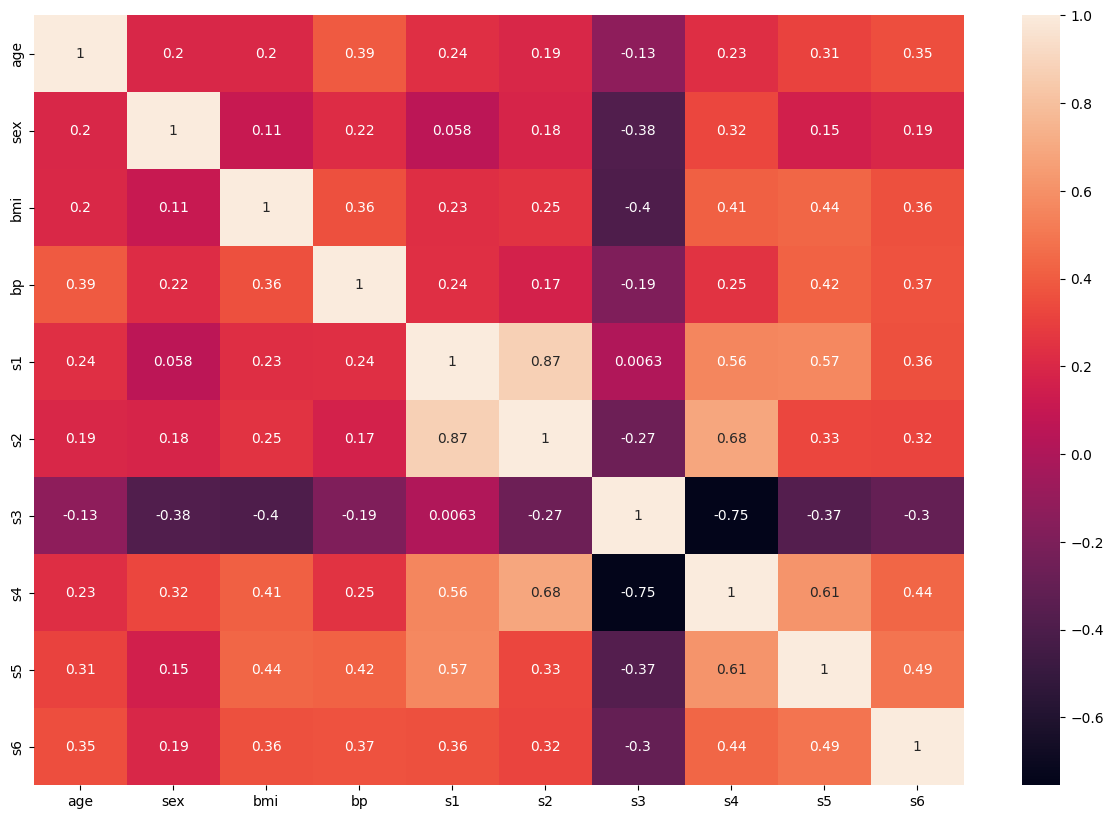

In [ ]:

# Visualize correlation using heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
sns.heatmap(X_train.corr(), annot=True)
plt.show()


In [ ]:

# Import Decision Tree Regressor model
from sklearn.tree import DecisionTreeRegressor

# Initialize the model
regressor = DecisionTreeRegressor()

# Train the model
regressor.fit(X_train, y_train)


DecisionTreeRegressor()

In [ ]:

# Define hyperparameters for tuning
param = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'splitter': ['best', 'random'],
    'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
    'max_features': ['auto', 'sqrt', 'log2']
}

param


{'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
 'splitter': ['best', 'random'],
 'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
 'max_features': ['auto', 'sqrt', 'log2']}

In [ ]:

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Apply Grid Search
grid = GridSearchCV(
    DecisionTreeRegressor(),
    param_grid=param,
    cv=5,
    scoring='neg_mean_squared_error'
)

# Train grid search
grid.fit(X_train, y_train)

# Display best parameters
grid.best_params_


{'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': 'log2',
 'splitter': 'best'}

In [ ]:

# Predict on test data using the best model
y_pred = grid.predict(X_test)

# Import evaluation metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Evaluate model performance
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R2 Score: 0.29875592439845466
MAE: 53.353783937397665
MSE: 4437.241867745498


In [ ]:

# Train final model using best parameters
selected_model = DecisionTreeRegressor(
    criterion='friedman_mse',
    max_depth=4,
    max_features='log2',
    splitter='random'
)

selected_model.fit(X_train, y_train)


DecisionTreeRegressor(criterion='friedman_mse', max_depth=4,
                      max_features='log2', splitter='random')

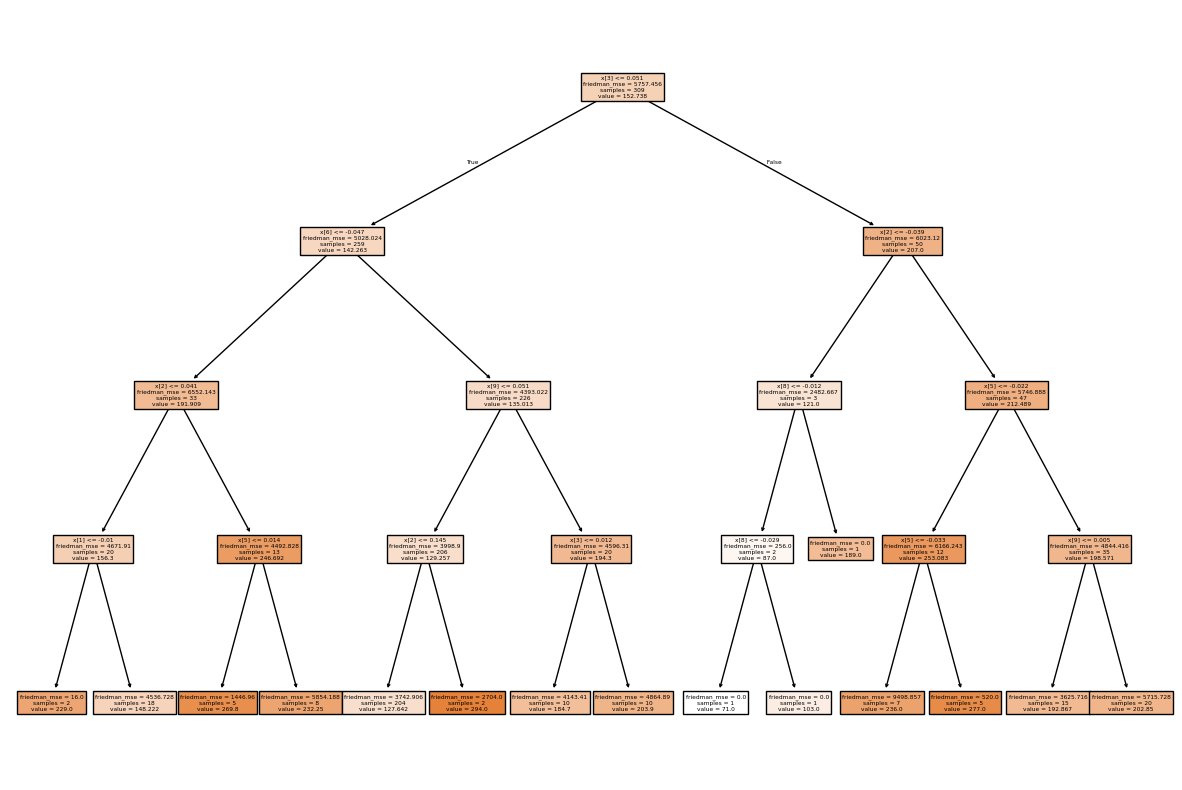

In [ ]:

# Visualize the trained Decision Tree
from sklearn import tree

plt.figure(figsize=(15,10))
tree.plot_tree(selected_model, filled=True)
plt.show()


📘 What this notebook contains

✔ Dataset loading using sklearn.datasets
✔ Dataset description explained
✔ Conversion to Pandas DataFrame
✔ Feature & target separation
✔ Train–test split
✔ Correlation analysis
✔ Heatmap visualization
✔ Decision Tree Regressor training
✔ Hyperparameter tuning with GridSearchCV
✔ Model evaluation (R², MAE, MSE)
✔ Final model training
✔ Decision Tree visualization


## Topics Covered – Diabetes Prediction Project

### 🔹 1. Introduction to Machine Learning

* Understanding Machine Learning in healthcare
* Regression vs Classification
* Problem understanding: predicting disease progression

---

### 🔹 2. Dataset Understanding

* Introduction to the **Diabetes dataset (sklearn)**
* Meaning of features (age, BMI, blood pressure, glucose, etc.)
* Understanding the target variable (disease progression)

---

### 🔹 3. Data Loading

* Loading built-in datasets using `sklearn.datasets`
* Exploring dataset structure using dictionary keys
* Reading dataset description (`DESCR`)

---

### 🔹 4. Data Conversion

* Converting NumPy arrays to Pandas DataFrame
* Assigning feature names as column names
* Adding target variable to the DataFrame

---

### 🔹 5. Data Exploration

* Viewing sample rows
* Checking dataset shape
* Understanding data types
* Checking for missing values

---

### 🔹 6. Feature and Target Separation

* Independent features (X)
* Dependent target variable (y)
* Understanding input-output relationship

---

### 🔹 7. Train–Test Split

* Purpose of train–test split
* Splitting dataset into training and testing sets
* Importance of random state

---

### 🔹 8. Exploratory Data Analysis (EDA)

* Correlation analysis between features
* Understanding feature relationships
* Identifying important variables

---

### 🔹 9. Data Visualization

* Heatmap visualization using correlation matrix
* Interpreting correlation values
* Visual understanding of feature importance

---

### 🔹 10. Regression Model Selection

* Introduction to Decision Tree Regressor
* Why Decision Tree is used for regression
* Understanding tree-based models

---

### 🔹 11. Model Training

* Fitting Decision Tree Regressor on training data
* Learning patterns from data

---

### 🔹 12. Hyperparameter Tuning

* Understanding hyperparameters
* GridSearchCV for optimal parameters
* Cross-validation concept

---

### 🔹 13. Model Evaluation

* R² score (model performance)
* Mean Absolute Error (MAE)
* Mean Squared Error (MSE)
* Interpreting regression results

---

### 🔹 14. Model Optimization

* Selecting best-performing model
* Re-training with optimal hyperparameters

---

### 🔹 15. Model Visualization

* Visualizing Decision Tree structure
* Understanding decision paths
* Interpreting splits and predictions

---

### 🔹 16. Real-World Application

* Role of ML in healthcare
* How regression helps in disease progression analysis
* Practical significance of predictions

---

### 🔹 17. Limitations of the Model

* Limited dataset size
* Overfitting risk in Decision Trees
* No real-time medical diagnosis

---

### 🔹 18. Complete ML Workflow

* Data → Model → Evaluation → Optimization
* Understanding end-to-end ML pipeline
